# Transfer Learning v2 – Research-First Vietnam Pipeline

### 🔧 Changelog v3.2 (Research Core):
1. ✅ **Giản lược feature về lõi hợp lệ**: ưu tiên calendar + weather cơ bản + target history, loại bỏ feature khó giải thích hoặc dễ gây lệch miền.
2. ✅ **Chuẩn hóa split theo thời gian**: tách train / validation / test cuối chuỗi để đánh giá đúng khả năng tổng quát hóa.
3. ✅ **Cố định precision ổn định**: ưu tiên FP32 trên GPU thay vì mixed precision không ổn định với RNN/TFT trong môi trường hiện tại.
4. ✅ **Sửa đánh giá và vẽ biểu đồ**: tách metric theo split và dùng logic an toàn hơn khi lấy prediction output.

*(Hãy chạy notebook theo thứ tự từ trên xuống)*

In [1]:
# ── Cell 1: Import ────────────────────────────────────────────────────────────
import os, json, shutil, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import r2_score

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision('high')

config_path = Path('checkpoint/model_config_v2.json')
if config_path.exists():
    with open(config_path, 'r') as f:
        model_cfg = json.load(f)
    LOG_TRANSFORM = model_cfg.get('LOG_TRANSFORM', True)
    print(f'✅ Config loaded – LOG_TRANSFORM={LOG_TRANSFORM}')
else:
    LOG_TRANSFORM = True
    print('⚠️ model_config_v2.json not found, LOG_TRANSFORM=True')

CHECKPOINT_PATH = 'checkpoint/tft_v2_best.ckpt'
print(f'Pretrained: {CHECKPOINT_PATH} | Exists: {os.path.exists(CHECKPOINT_PATH)}')

INFO: Seed set to 42


[23:14:02] INFO     Seed set to 42                                   seed.py:57
✅ Config loaded – LOG_TRANSFORM=True
Pretrained: checkpoint/tft_v2_best.ckpt | Exists: True


In [2]:
# ── Cell 2: Load & xử lý dữ liệu Vietnam ─────────────────────────────────────
path_vn = Path('data/processed/VN_data/full_vietnam_monthly_merger.csv')
df_main = pd.read_csv(path_vn, sep=',')

if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = df_main.rename(columns={
    'generation_twh': 'generation_TWh',
    'precip_mean': 'precipitation',
    'solar_mean': 'solar',
    'humidity_mean': 'humidity',
    'temp_mean': 'temperature'
})

SPARSE_THRESHOLD = 0.60
raw_target = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
zero_ratio = pd.DataFrame({'series': df_vn['series'], 'raw_target': raw_target}).groupby('series')['raw_target'].apply(lambda s: (s == 0).mean())
sparse_series = zero_ratio[zero_ratio >= SPARSE_THRESHOLD].index.tolist()
if sparse_series:
    df_vn = df_vn[~df_vn['series'].isin(sparse_series)].copy()

df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0).replace(0, 1e-4).clip(lower=1e-4)

if LOG_TRANSFORM:
    df_vn['generation_TWh'] = np.log1p(df_vn['generation_TWh'])

df_vn['date'] = pd.to_datetime(df_vn['date'])
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

min_date = df_vn['date'].min()
df_vn['time_idx'] = ((df_vn['date'].dt.year - min_date.year) * 12 + (df_vn['date'].dt.month - min_date.month)).astype(int)
df_vn['month'] = df_vn['date'].dt.month.astype(str)
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12.0)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12.0)

# Chỉ làm sạch các biến ngoại sinh cơ bản; không đưa feature khó giải thích vào lõi transfer
basic_exo_cols = ['precipitation', 'solar', 'humidity', 'temperature']
for c in basic_exo_cols:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill())
        median_c = pd.to_numeric(df_vn[c], errors='coerce').median()
        df_vn[c] = pd.to_numeric(df_vn[c], errors='coerce').fillna(median_c if pd.notna(median_c) else 0)
        q01, q99 = df_vn[c].quantile([0.01, 0.99])
        df_vn[c] = df_vn[c].clip(lower=q01, upper=q99)

print(f'✅ Khởi tạo chuỗi thành công. Kích thước dữ liệu sau lọc: {len(df_vn)}')

✅ Khởi tạo chuỗi thành công. Kích thước dữ liệu sau lọc: 360


In [3]:
# ── Cell 3: Tạo TimeSeriesDataSet ─────────────────────────────────────────────
# Giữ feature lõi gọn, đúng logic nghiên cứu cho transfer
max_encoder_length = 24
max_prediction_length = 6
batch_size = 32

USE_EXTENDED_TRANSFER_FEATURES = False

# Cần đủ lịch sử cho train/val/test non-overlap
min_len = max_encoder_length + max_prediction_length + max_prediction_length
series_len = df_vn.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n')
valid_groups = series_len.loc[series_len['n'] >= min_len, ['entity', 'series']]
df_vn_valid = df_vn.merge(valid_groups, on=['entity', 'series'], how='inner').copy()
df_vn_valid = df_vn_valid.reset_index(drop=True)

if df_vn_valid.empty:
    raise ValueError('No series long enough!')

max_time_idx = int(df_vn_valid['time_idx'].max())
train_cutoff = max_time_idx - 12
val_cutoff = max_time_idx - 6

known_candidates = [
    'time_idx',
    'month_sin',
    'month_cos',
    'precipitation',
    'temperature',
]
unknown_candidates = [
    'generation_TWh',
]

if USE_EXTENDED_TRANSFER_FEATURES:
    known_candidates += ['humidity', 'solar']

known_reals = [c for c in known_candidates if c in df_vn_valid.columns]
unknown_reals = [c for c in unknown_candidates if c in df_vn_valid.columns]

normalizer = GroupNormalizer(
    groups=['entity', 'series'],
    center=True,
 )

training = TimeSeriesDataSet(
    df_vn_valid[lambda x: x.time_idx <= train_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=12,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=normalizer,
    lags={'generation_TWh': [1, 3, 6, 12]},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation_df = df_vn_valid[lambda x: x.time_idx <= val_cutoff].copy()
test_df = df_vn_valid.copy()

validation = TimeSeriesDataSet.from_dataset(
    training,
    validation_df,
    min_prediction_idx=train_cutoff + 1,
    stop_randomization=True,
)

testset = TimeSeriesDataSet.from_dataset(
    training,
    test_df,
    min_prediction_idx=val_cutoff + 1,
    stop_randomization=True,
)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)
test_loader = testset.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print(f'✅ Windows – train: {len(training)}, val: {len(validation)}, test: {len(testset)}')
print(f'✅ USE_EXTENDED_TRANSFER_FEATURES={USE_EXTENDED_TRANSFER_FEATURES}')

✅ Windows – train: 215, val: 65, test: 65
✅ USE_EXTENDED_TRANSFER_FEATURES=False


In [4]:
# ── Cell 4: Khởi tạo model & load pretrained ─────────────────────────────────
os.makedirs('checkpoint', exist_ok=True)

# Ưu tiên GPU nếu có, nhưng giữ FP32 để tránh lỗi dtype/mixed precision của TFT/RNN
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
devices = 1
precision = 32
print(f'🚀 Transfer accelerator: {accelerator} | devices={devices} | precision={precision}')

tft_vn = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-4,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.25,
    hidden_continuous_size=64,
    loss=QuantileLoss(),
    log_interval=20,
    reduce_on_plateau_patience=5,
    optimizer='adamw',
    weight_decay=1e-2,
    mask_bias=-1e4,
    output_size=7,
 )

MIN_MATCH_RATIO = 0.90
STRONG_MATCH_RATIO = 0.97
n_t = n_m = p_t = p_m = 0
match_ratio = 0.0

if os.path.exists(CHECKPOINT_PATH):
    pretrained_dict = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)['state_dict']
    model_dict = tft_vn.state_dict()
    matched_dict = {
        k: v for k, v in pretrained_dict.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }

    p_t = sum(v.numel() for v in model_dict.values())
    p_m = sum(v.numel() for v in matched_dict.values())
    n_t, n_m = len(model_dict), len(matched_dict)
    match_ratio = p_m / max(p_t, 1)

    print(f'🔁 Tensors: {n_m}/{n_t} ({n_m/max(n_t,1):.1%}) | Params: {p_m/1e3:.1f}k/{p_t/1e3:.1f}k ({match_ratio:.1%})')

    if match_ratio < MIN_MATCH_RATIO:
        raise RuntimeError(
            f'Checkpoint mismatch quá lớn ({match_ratio:.1%} < {MIN_MATCH_RATIO:.0%}). '
            'Dừng để tránh transfer sai cấu hình.'
        )

    model_dict.update(matched_dict)
    tft_vn.load_state_dict(model_dict)
else:
    raise FileNotFoundError(f'Không tìm thấy pretrained checkpoint: {CHECKPOINT_PATH}')

# Pha 3: freeze policy thích nghi theo chất lượng nạp checkpoint
if match_ratio >= STRONG_MATCH_RATIO:
    FREEZE_STRATEGY = 'full_backbone_freeze'
else:
    FREEZE_STRATEGY = 'partial_backbone_freeze'

print(f'✅ Freeze strategy: {FREEZE_STRATEGY}')

🚀 Transfer accelerator: gpu | devices=1 | precision=32
🔁 Tensors: 429/458 (93.7%) | Params: 1422.3k/1440.9k (98.7%)
✅ Freeze strategy: full_backbone_freeze


In [5]:
# ── Cell 5: Stage 1 – Warm-up (frozen backbone) ───────────────────────────────
print('== STAGE 1: Warm-up (adaptive freeze) ==')

if FREEZE_STRATEGY == 'full_backbone_freeze':
    FREEZE_LAYERS = ['lstm_encoder', 'lstm_decoder', 'multihead_attn', 'post_attn_norm']
else:
    # Match không đủ cao: chỉ freeze attention, giữ LSTM trainable để tránh khóa backbone sai
    FREEZE_LAYERS = ['multihead_attn', 'post_attn_norm']

print(f"Stage 1 freeze layers: {FREEZE_LAYERS}")
for name, param in tft_vn.named_parameters():
    if any(f in name for f in FREEZE_LAYERS):
        param.requires_grad = False
    else:
        param.requires_grad = True

# Giữ FP32 để ưu tiên ổn định cho RNN/TFT trong môi trường hiện tại
stage1_precision = precision

# Tránh lỗi cudnn RNN backward ở workflow fit nhiều stage
torch.backends.cudnn.enabled = False
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

tft_vn.hparams.learning_rate = 1e-5
trainer_warmup = pl.Trainer(
    max_epochs=2,
    accelerator=accelerator,
    devices=devices,
    precision=stage1_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    enable_model_summary=False,
 )
trainer_warmup.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

tft_vn.hparams.learning_rate = 8e-5
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

cb_es_s1 = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=8, mode='min')
cb_ckpt_s1 = ModelCheckpoint(monitor='val_loss', mode='min', filename='tft_vn_s1-{epoch:02d}', save_top_k=1)
trainer_s1 = pl.Trainer(
    max_epochs=12,
    accelerator=accelerator,
    devices=devices,
    precision=stage1_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    callbacks=[cb_es_s1, cb_ckpt_s1],
    enable_model_summary=False,
 )
trainer_s1.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: GPU available: True (cuda), used: True


== STAGE 1: Warm-up (adaptive freeze) ==
Stage 1 freeze layers: ['lstm_encoder', 'lstm_decoder', 'multihead_attn', 'post_attn_norm']
[23:14:03] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


Output()

INFO: `Trainer.fit` stopped: `max_epochs=12` reached.


[23:14:51] INFO     `Trainer.fit` stopped: `max_epochs=12`      fit_loop.py:192
                    reached.                                                   


In [6]:
# ── Cell 6: Stage 2 – Partial unfreeze (LSTM thaw) ───────────────────────────
print('== STAGE 2: Partial unfreeze (LSTM thaw) ==')
if cb_ckpt_s1.best_model_path and os.path.exists(cb_ckpt_s1.best_model_path):
    ckpt = torch.load(cb_ckpt_s1.best_model_path, map_location='cpu', weights_only=False)
    tft_vn.load_state_dict(ckpt['state_dict'])

STILL_FROZEN = ['multihead_attn', 'post_attn_norm']
for name, param in tft_vn.named_parameters():
    param.requires_grad = not any(f in name for f in STILL_FROZEN)

# Giữ FP32 xuyên suốt để tránh lỗi dtype ở giai đoạn thaw
stage23_precision = precision

tft_vn.hparams.learning_rate = 3e-5
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

cb_es_s2 = EarlyStopping(monitor='val_loss', min_delta=5e-5, patience=10, mode='min')
cb_ckpt_s2 = ModelCheckpoint(monitor='val_loss', mode='min', filename='tft_vn_s2-{epoch:02d}', save_top_k=1)
trainer_s2 = pl.Trainer(
    max_epochs=30,
    accelerator=accelerator,
    devices=devices,
    precision=stage23_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    callbacks=[cb_es_s2, cb_ckpt_s2],
    enable_model_summary=False,
 )
trainer_s2.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

== STAGE 2: Partial unfreeze (LSTM thaw) ==


INFO: GPU available: True (cuda), used: True


           INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


Output()

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.


[23:16:18] INFO     `Trainer.fit` stopped: `max_epochs=30`      fit_loop.py:192
                    reached.                                                   


In [7]:
# ── Cell 7: Stage 3 – Full finetune ──────────────────────────────────────────
print('== STAGE 3: Full finetune (all layers) ==')
if cb_ckpt_s2.best_model_path and os.path.exists(cb_ckpt_s2.best_model_path):
    ckpt = torch.load(cb_ckpt_s2.best_model_path, map_location='cpu', weights_only=False)
    tft_vn.load_state_dict(ckpt['state_dict'])

for param in tft_vn.parameters():
    param.requires_grad = True

# Giữ FP32 xuyên suốt để tránh lỗi dtype ở giai đoạn fine-tune cuối
stage23_precision = precision

tft_vn.hparams.learning_rate = 1e-5
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

cb_es_s3 = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=12, mode='min')
cb_ckpt_s3 = ModelCheckpoint(dirpath='checkpoint', monitor='val_loss', mode='min', filename='tft_vn_best_final-{epoch:02d}', save_top_k=1)
trainer_s3 = pl.Trainer(
    max_epochs=40,
    accelerator=accelerator,
    devices=devices,
    precision=stage23_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    callbacks=[cb_es_s3, cb_ckpt_s3],
    enable_model_summary=False,
 )
trainer_s3.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer_vn = trainer_s3

== STAGE 3: Full finetune (all layers) ==


INFO: GPU available: True (cuda), used: True


[23:16:19] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


Output()

INFO: `Trainer.fit` stopped: `max_epochs=40` reached.


[23:18:08] INFO     `Trainer.fit` stopped: `max_epochs=40`      fit_loop.py:192
                    reached.                                                   


In [8]:
# ── Cell 8: Đánh giá (Validation + Test) ──────────────────────────────────────
def _unpack_prediction_result(result):

    predictions = result

    x_data = None

    index_data = None

    if hasattr(result, 'output'):

        predictions = result.output

        x_data = getattr(result, 'x', None)

        index_data = getattr(result, 'index', None)

    elif isinstance(result, tuple):

        predictions = result[0]

        if len(result) > 1:

            x_data = result[1]

        if len(result) > 2:

            index_data = result[2]

    return predictions, x_data, index_data



def _as_tensor(value):

    if isinstance(value, torch.Tensor):

        return value.detach().cpu()

    return torch.as_tensor(value).detach().cpu()



def _smape(y_true, y_pred, eps=1e-8):

    denom = np.abs(y_true) + np.abs(y_pred) + eps

    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100



def evaluate_loader(split_name, loader, dataset_ref):

    raw_result = tft_vn.predict(loader, mode='raw', return_x=True)

    raw_predictions, x_data, index_data = _unpack_prediction_result(raw_result)



    pred_result = tft_vn.predict(loader, mode='prediction', return_x=True)

    point_predictions, _, _ = _unpack_prediction_result(pred_result)



    actual_batches = []

    for _, y in loader:

        target = y[0] if isinstance(y, (list, tuple)) else y

        target = _as_tensor(target)

        if target.ndim == 1:

            target = target.unsqueeze(1)

        actual_batches.append(target)



    actual_tensor = torch.cat(actual_batches, dim=0)

    pred_tensor = _as_tensor(point_predictions)

    if pred_tensor.ndim == 1:

        pred_tensor = pred_tensor.unsqueeze(1)



    horizon = min(actual_tensor.shape[1], pred_tensor.shape[1]) if actual_tensor.ndim > 1 and pred_tensor.ndim > 1 else 1

    actual_tensor = actual_tensor[:, :horizon] if actual_tensor.ndim > 1 else actual_tensor.unsqueeze(1)

    pred_tensor = pred_tensor[:, :horizon] if pred_tensor.ndim > 1 else pred_tensor.unsqueeze(1)



    if LOG_TRANSFORM:

        actual_eval = torch.expm1(actual_tensor).clamp(min=0)

        pred_eval = torch.expm1(pred_tensor).clamp(min=0)

    else:

        actual_eval = actual_tensor

        pred_eval = pred_tensor



    flat_actual = actual_eval.reshape(-1)

    flat_pred = pred_eval.reshape(-1)

    valid_mask = torch.isfinite(flat_actual) & torch.isfinite(flat_pred)

    flat_actual = flat_actual[valid_mask]

    flat_pred = flat_pred[valid_mask]



    y_true_np = flat_actual.numpy()

    y_pred_np = flat_pred.numpy()



    mae = (flat_actual - flat_pred).abs().mean().item()

    rmse = torch.sqrt(((flat_actual - flat_pred) ** 2).mean()).item()

    wape = ((flat_actual - flat_pred).abs().sum() / (flat_actual.abs().sum() + 1e-8)).item() * 100

    r2 = r2_score(y_true_np, y_pred_np)

    smape = _smape(y_true_np, y_pred_np)



    print(f'\n--- {split_name.upper()} METRICS (TWh scale) ---')

    print(f'MAE  : {mae:.4f}')

    print(f'RMSE : {rmse:.4f}')

    print(f'WAPE : {wape:.4f}%')

    print(f'sMAPE: {smape:.4f}%')

    print(f'R²   : {r2:.4f}')



    series_report = None

    if index_data is None and x_data is not None and hasattr(dataset_ref, 'x_to_index'):

        try:

            index_data = dataset_ref.x_to_index(x_data)

        except Exception:

            index_data = None



    if index_data is not None and hasattr(index_data, 'columns') and 'series' in index_data.columns:

        series_labels = index_data['series'].astype(str).repeat(horizon).reset_index(drop=True)

        series_report = pd.DataFrame({

            'series': series_labels.iloc[:len(flat_actual)].values,

            'y_true': y_true_np,

            'y_pred': y_pred_np,

        })



        metrics_list = []

        for s, g in series_report.groupby('series'):

            mae_s = np.mean(np.abs(g['y_true'] - g['y_pred']))

            rmse_s = np.sqrt(np.mean((g['y_true'] - g['y_pred']) ** 2))

            wape_s = np.sum(np.abs(g['y_true'] - g['y_pred'])) / (np.sum(np.abs(g['y_true'])) + 1e-8) * 100

            smape_s = _smape(g['y_true'].values, g['y_pred'].values)

            metrics_list.append({

                'series': s,

                'mae': mae_s,

                'rmse': rmse_s,

                'wape': wape_s,

                'smape': smape_s,

            })



        series_metrics_df = pd.DataFrame(metrics_list).sort_values(['wape', 'smape'], ascending=False)



        print(f'\n--- {split_name.upper()} METRICS BY SERIES ---')

        for _, row in series_metrics_df.iterrows():

            print(f"{row['series']:>18} | MAE={row['mae']:.4f} | RMSE={row['rmse']:.4f} | WAPE={row['wape']:.2f}% | sMAPE={row['smape']:.2f}%")



        print(f'\n--- {split_name.upper()} TOP-3 SERIES CẦN ƯU TIÊN ---')

        print(series_metrics_df.head(3).to_string(index=False))



        series_report = {

            'points': series_report,

            'metrics': series_metrics_df,

        }



    return {

        'raw_result': raw_result,

        'raw_predictions': raw_predictions,

        'x_data': x_data,

        'metrics': {'mae': mae, 'rmse': rmse, 'wape': wape, 'smape': smape, 'r2': r2},

        'series_report': series_report,

        'actual_eval': actual_eval,

        'pred_eval': pred_eval,

    }



if cb_ckpt_s3.best_model_path and os.path.exists(cb_ckpt_s3.best_model_path):

    print(f'Load Final: {cb_ckpt_s3.best_model_path}')

    try:

        tft_vn = TemporalFusionTransformer.load_from_checkpoint(cb_ckpt_s3.best_model_path, weights_only=False)

    except Exception:

        tft_vn = TemporalFusionTransformer.load_from_checkpoint(cb_ckpt_s3.best_model_path)



torch.set_grad_enabled(False)

tft_vn.eval()



val_eval = evaluate_loader('validation', val_loader, validation)

test_eval = evaluate_loader('test', test_loader, testset)



plot_raw_predictions = val_eval['raw_predictions']

plot_x = val_eval['x_data']



os.makedirs('checkpoint', exist_ok=True)

trainer_vn.save_checkpoint('checkpoint/tft_vn_model_latest.ckpt')

shutil.copy(cb_ckpt_s3.best_model_path, 'checkpoint/tft_vn_model_best.ckpt')

Load Final: D:\WorkSpace\Study\NCKH\checkpoint\tft_vn_best_final-epoch=39-v1.ckpt


INFO: GPU available: True (cuda), used: True


[23:18:10] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


INFO: `weights_only` was not set, defaulting to `False`.



--- TEST METRICS (TWh scale) ---
MAE  : 0.8221
RMSE : 1.2104
WAPE : 15.4035%
sMAPE: 20.8953%
R²   : 0.9314

--- TEST METRICS BY SERIES ---
               Gas | MAE=0.8204 | RMSE=0.8631 | WAPE=47.56% | sMAPE=42.08%
             Hydro | MAE=2.3055 | RMSE=2.4635 | WAPE=19.90% | sMAPE=22.11%
              Wind | MAE=0.1773 | RMSE=0.2198 | WAPE=19.24% | sMAPE=19.81%
             Solar | MAE=0.3882 | RMSE=0.4967 | WAPE=17.45% | sMAPE=16.28%
              Coal | MAE=0.4189 | RMSE=0.4657 | WAPE=4.10% | sMAPE=4.20%

--- TEST TOP-3 SERIES CẦN ƯU TIÊN ---
series      mae     rmse      wape     smape
   Gas 0.820414 0.863107 47.560219 42.075626
 Hydro 2.305543 2.463493 19.903973 22.114294
  Wind 0.177321 0.219781 19.239195 19.810644
           INFO     `weights_only` was not set,     checkpoint_connector.py:455
                    defaulting to `False`.                                     


'checkpoint/tft_vn_model_best.ckpt'

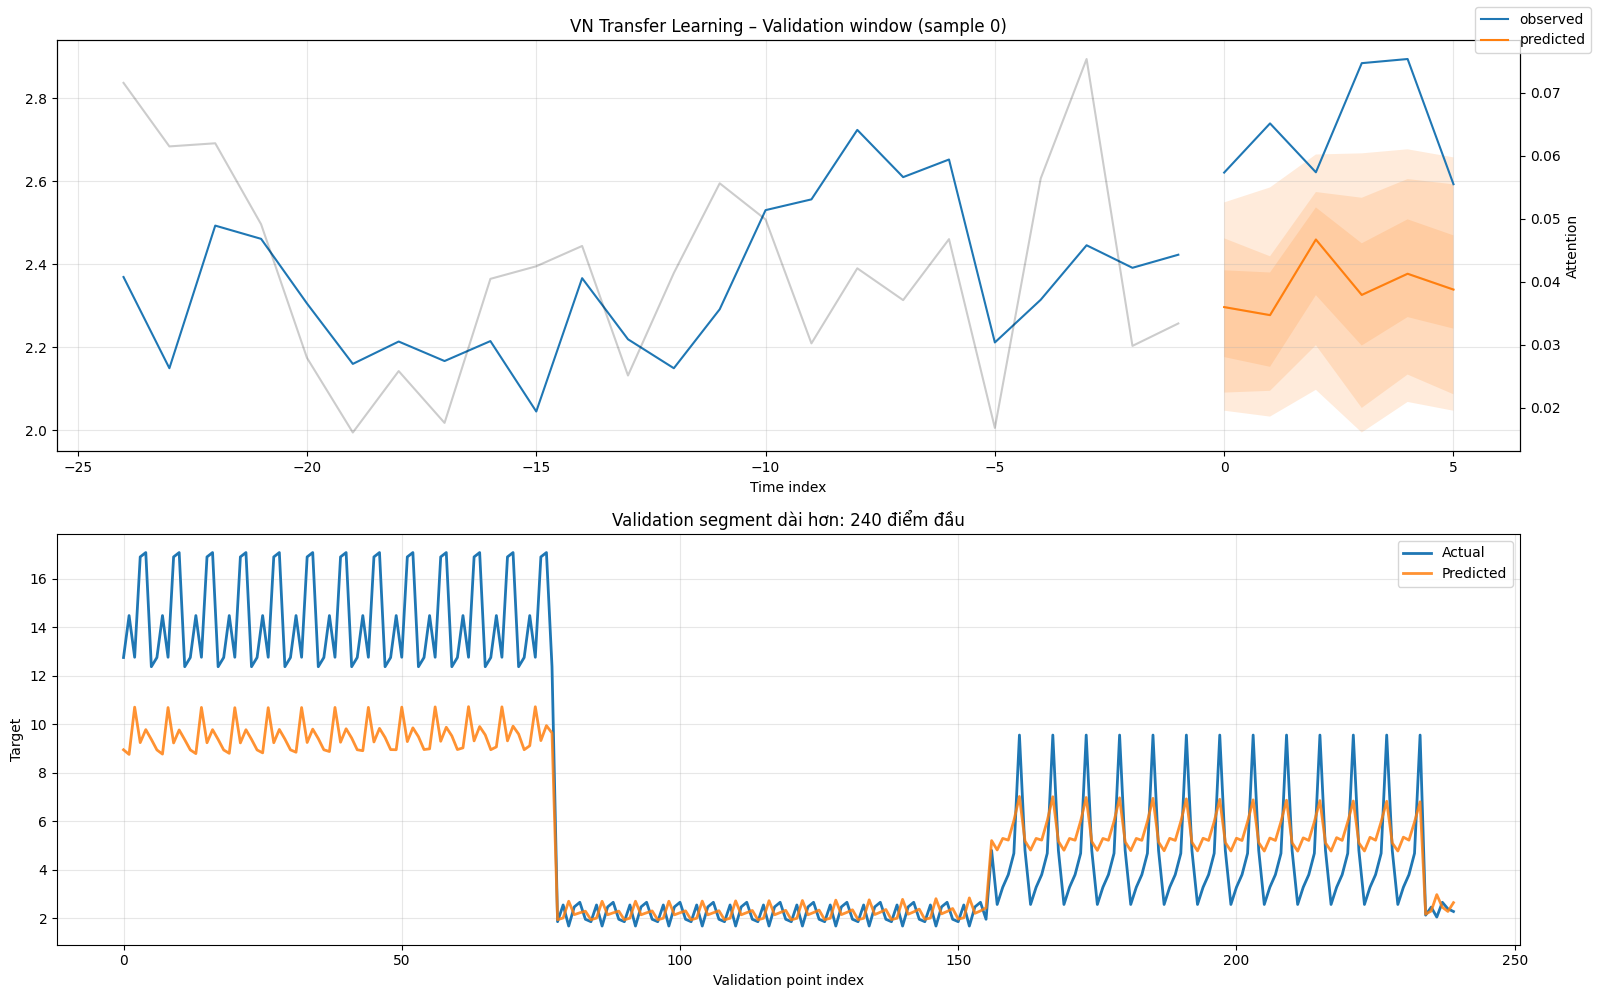

In [9]:
# ── Cell 9: Vẽ biểu đồ ─────────────────────────────────────────────────────
try:
    if plot_x is not None and plot_raw_predictions is not None:
        fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

        # Panel 1: một validation window chuẩn của TFT để xem trực quan đầu ra từng horizon
        _ = tft_vn.plot_prediction(plot_x, plot_raw_predictions, idx=0, add_loss_to_title=True, ax=axes[0])
        axes[0].set_title('VN Transfer Learning – Validation window (sample 0)')
        axes[0].grid(True, alpha=0.3)

        # Panel 2: một đoạn validation dài hơn, lấy từ toàn bộ output dự đoán để đối chiếu metrics
        actual_eval = val_eval.get('actual_eval')
        pred_eval = val_eval.get('pred_eval')
        if actual_eval is not None and pred_eval is not None:
            actual_flat = actual_eval.detach().cpu().reshape(-1).numpy()
            pred_flat = pred_eval.detach().cpu().reshape(-1).numpy()
            valid_mask = np.isfinite(actual_flat) & np.isfinite(pred_flat)
            actual_flat = actual_flat[valid_mask]
            pred_flat = pred_flat[valid_mask]

            plot_points = min(240, len(actual_flat))
            if plot_points > 0:
                x_axis = np.arange(plot_points)
                axes[1].plot(x_axis, actual_flat[:plot_points], label='Actual', linewidth=2)
                axes[1].plot(x_axis, pred_flat[:plot_points], label='Predicted', linewidth=2, alpha=0.85)
                axes[1].set_title(f'Validation segment dài hơn: {plot_points} điểm đầu')
                axes[1].set_xlabel('Validation point index')
                axes[1].set_ylabel('Target')
                axes[1].grid(True, alpha=0.3)
                axes[1].legend()
            else:
                axes[1].text(0.5, 0.5, 'No validation points to plot', ha='center', va='center')
                axes[1].set_axis_off()
        else:
            axes[1].text(0.5, 0.5, 'No validation tensor available', ha='center', va='center')
            axes[1].set_axis_off()

        plt.tight_layout()
        plt.show()
    else:
        print('⚠️ Không thể vẽ biểu đồ vì dữ liệu plot trả về lỗi/trống')
except Exception as e:
    print(f'Plot error: {e}')